# 04 · Compare investigation strategies fairly

Created by Shivam Bharadwaj · [Benchmark home](../README.md) · [Protocol](../PROTOCOL.md)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/build-goallab/notebooks/04_evaluation_and_search.ipynb)

**Question:** does more investigation compute produce more verified answers?

You will reproduce the summary from all reference outcomes, inspect variation across training seeds, calculate support-aware calibration, and audit the cost of discarded search branches. The result may favor the simple rule. That is an engineering finding, not a reason to hide it.

**Prerequisites:** benchmark labs 01–03. **Outcome:** an auditable comparison at fixed work budgets.

![The investigation loop and independent final evaluation](../architecture.svg)

**Run:** restart the kernel and run all cells. Each lab is independent. The default uses CPU, no API key, and no pretrained-model download. Colab runs need the published repository revision. Code is MIT; educational text and plots are CC BY 4.0.

In [1]:
import sys, subprocess, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p/'rl_course/goallab_benchmark.py').exists()), None)
if ROOT is None and IN_COLAB:
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git','clone','--depth','1','https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git',str(ROOT)],check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','numpy','matplotlib','torch'],check=True)
if ROOT is None or not (ROOT/'rl_course/goallab_benchmark.py').exists():
    raise FileNotFoundError('Use the full repository revision containing GoalLab-v2.')
sys.path.insert(0,str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import display, Markdown
from rl_course import goallab_benchmark as g, goallab_training as train
torch.set_num_threads(2)
ARTIFACTS = Path(tempfile.mkdtemp(prefix='goallab-lab-'))
plt.rcParams.update({'figure.figsize':(9,4),'figure.facecolor':'#f5f1e8','axes.facecolor':'#f5f1e8',
    'axes.spines.top':False,'axes.spines.right':False,'axes.prop_cycle':plt.cycler(color=['#af824a','#657951','#87708c','#292332'])})
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+'|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(str(v) for v in row)+' |' for row in rows)))
print(g.VERSION, '| Torch',torch.__version__, '| device: CPU | artifacts:',ARTIFACTS)

GoalLab-v2 | Torch 2.11.0+cu130 | device: CPU | artifacts: /tmp/goallab-lab-qkqvha31


## 1. Load every reference outcome

The saved report contains all evaluated outcomes. A deterministic prefix retains full traces for the demo; the benchmark command regenerates all traces. The default reference has three training seeds, fifty cases per split, three budgets, and five methods. These are repeated cases across seeds, not 4500 independent task templates.

In [2]:
report=json.loads((ROOT/'projects/goallab/build-goallab/results.json').read_text())
print(report['config'])
records=report['records']
recomputed=train.aggregate(records)
assert recomputed==report['summary']
print('Recomputed all summary rows from',len(records),'outcomes.')
table(['Set','Budget','Method','Success','Cost'],[[r['split'],r['budget'],r['method'],f"{r['success']:.1%}",round(r['average_cost'],2)] for r in recomputed if r['budget']==8])

{'episodes': 2400, 'cases_per_split': 50, 'seeds': [7, 19, 31], 'budgets': [4, 8, 12]}
Recomputed all summary rows from 4500 outcomes.


| Set | Budget | Method | Success | Cost |
|---|---|---|---|---|
| GoalLab-Challenge | 8 | DQN | 96.0% | 7.07 |
| GoalLab-Challenge | 8 | Greedy | 100.0% | 7.96 |
| GoalLab-Challenge | 8 | PPO | 66.7% | 5.0 |
| GoalLab-Challenge | 8 | PPO + Verifier | 66.7% | 8.0 |
| GoalLab-Challenge | 8 | RL + Test-Time Search | 0.0% | 7.33 |
| GoalLab-Test | 8 | DQN | 100.0% | 7.01 |
| GoalLab-Test | 8 | Greedy | 100.0% | 4.22 |
| GoalLab-Test | 8 | PPO | 66.7% | 5.0 |
| GoalLab-Test | 8 | PPO + Verifier | 66.7% | 8.0 |
| GoalLab-Test | 8 | RL + Test-Time Search | 48.0% | 7.01 |

## 2. Inspect budget curves and seed variation

The horizontal axis is total work units: tool costs plus learned-verifier scoring. It is not wall-clock time, FLOPs, or just the selected trajectory's calls. Branches that lose the search still consumed work.

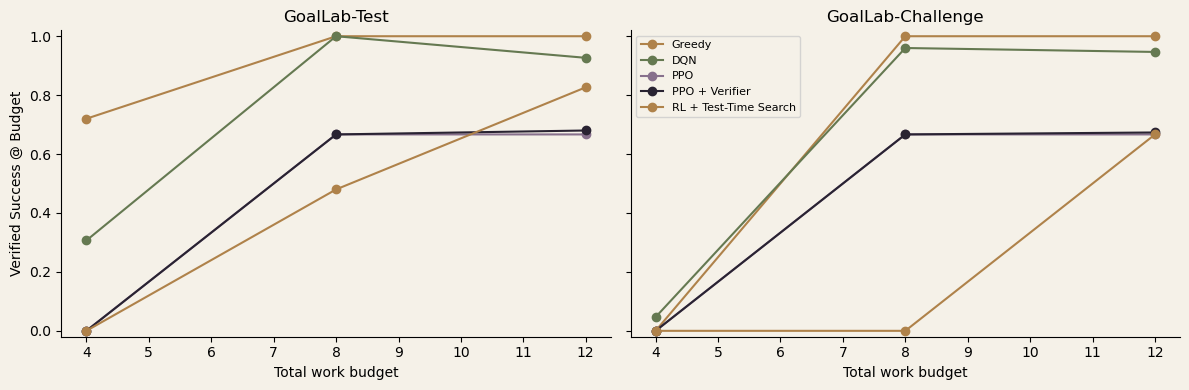

PPO seed-specific success: {'7': 1.0, '19': 1.0, '31': 0.0}


In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,split in zip(axes,g.SPLITS[1:]):
    for method in ['Greedy','DQN','PPO','PPO + Verifier','RL + Test-Time Search']:
        rows=sorted([r for r in recomputed if r['split']==split and r['method']==method],key=lambda r:r['budget'])
        ax.plot([r['budget'] for r in rows],[r['success'] for r in rows],marker='o',label=method)
    ax.set_title(split);ax.set_xlabel('Total work budget');ax.set_ylim(-.02,1.02)
axes[0].set_ylabel('Verified Success @ Budget');axes[1].legend(fontsize=8);plt.tight_layout();plt.show()
row=next(r for r in recomputed if r['split']=='GoalLab-Test' and r['budget']==8 and r['method']=='PPO')
print('PPO seed-specific success:',row['seed_success'])

## 3. Replay final verification from the collected evidence

Reconstruct cases by ID, then check recorded artifacts against final observations. This recomputes grading only; it does not run policies or change their decisions. A changed evaluator should be versioned because it changes the meaning of the benchmark.

In [4]:
for record in records:
    split,level,index=record['case'].split('/')
    case=g.make_case(int(index),split,int(level))
    assert g.verify(case,record['artifact'],record['final_observation'])==record['evaluation']
print('All final evaluations reproduced.')
trace=next(r for r in records if r['method']=='RL + Test-Time Search' and r.get('events'))
assert sum(e['cost'] for e in trace['events'])==trace['cost']
table(['Action','Branch','Cost'],[[e['action'],e.get('branch','selected'),e['cost']] for e in trace['events']])

All final evaluations reproduced.


| Action | Branch | Cost |
|---|---|---|
| search computation | selected | 1 |
| inspect metadata 6 | selected | 1 |
| search computation | selected | 1 |
| STOP: answer 1, confidence 50% | selected | 1 |

## 4. Confidence must refer to a defined event

Here confidence predicts **correct and supported completion**, not merely guessing the right number. For a 0.95-confidence unsupported answer, the target is zero and Brier loss is 0.9025. Conditional calibration excludes abstentions, so coverage must accompany it. A method cannot be called reliable just because it only answers one easy case.

In [5]:
print('Confident unsupported answer Brier:',(.95-0)**2)
table(['Method','Coverage','Brier','ECE'],[[r['method'],f"{r['answer_coverage']:.1%}",r['brier'],r['ece']] for r in recomputed if r['split']=='GoalLab-Test' and r['budget']==8])

Confident unsupported answer Brier: 0.9025


| Method | Coverage | Brier | ECE |
|---|---|---|---|
| DQN | 100.0% | 0.07410000000000001 | 0.20866666666666653 |
| Greedy | 100.0% | 0.0025000000000000044 | 0.04999999999999982 |
| PPO | 66.7% | 0.14605 | 0.341 |
| PPO + Verifier | 100.0% | 0.085 | 0.2 |
| RL + Test-Time Search | 82.7% | 0.10629032258064514 | 0.2387096774193548 |

## 5. Change a constraint: include the cost of failures

Calculate total cost per verified completion. Predict which ranking changes when failures consume resources. If there are no successes, the ratio is undefined, not zero. Keep the full denominator; deleting failed runs would fabricate efficiency.

In [6]:
rows=[]
for method in ['Greedy','DQN','PPO','PPO + Verifier','RL + Test-Time Search']:
    subset=[r for r in records if r['split']=='GoalLab-Test' and r['budget']==8 and r['method']==method]
    wins=sum(r['evaluation']['success'] for r in subset)
    rows.append([method,sum(r['cost'] for r in subset)/wins if wins else 'undefined',wins,len(subset)])
table(['Method','Cost per verified completion','Verified','Assigned'],rows)

| Method | Cost per verified completion | Verified | Assigned |
|---|---|---|---|
| Greedy | 4.22 | 150 | 150 |
| DQN | 7.013333333333334 | 150 | 150 |
| PPO | 7.5 | 100 | 150 |
| PPO + Verifier | 12.0 | 100 | 150 |
| RL + Test-Time Search | 14.61111111111111 | 72 | 150 |

## Interpret the result

The search implementation adds a rule proposal to learned proposals and uses a learned verifier and critic. Any benefit belongs to that hybrid, not solely to RL. Training episodes are matched but action counts and extra verifier training are not identical. The public challenge is a reproducible stress test, not a private leaderboard. Read [the protocol](../PROTOCOL.md) before making a broader claim.

**Next:** [Investigation demo](05_investigation_demo.ipynb).